# Описательная статистика

**Описательная статистика** — это способ кратко описать данные, не делая выводов о чём-то большем. Просто «сжать» таблицу из 10000 строк в 5–10 чисел, которые её характеризуют

## Меры центральной тенденции

### 1. Среднее арифметическое

Уже описывалось в "Основных статистических понятиях"

### 2. Медиана

Уже описывалось в "Основных статистических понятиях"

### 3. Мода

Уже описывалось в "Основных статистических понятиях"

### 4. Усечённое среднее

**Усечённое среднее** - это среднее без крайних значений

Алгорит:
1. Сортировка данных
2. Отбросить k% с каждого конца
3. Посчитай среднее по оставшимся

### 5. Взвешенное среднее

**Взвешенное среднее** - это среднее, где у каждого значения свой вес
$$
\bar{x}_w = \frac{w_1x_1 + w_2x_2 + ... + w_nx_n}{w_1 + w_2 + ... + w_n}
$$

Пример, в классе две группы:
- Группа A: 20 человек, средний балл 4.5
- Группа B: 10 человек, средний балл 3.5

Обычное среднее (неверно):
$$
\frac{4.5 + 3.5}{2} = 4
$$
Она не учитывает, что в группе разное количество человек

Взвешенное среднее:
$$
\bar{x}_w = \frac{20 * 4.5 + 10 * 3.5}{20 + 10} \approx 4.17
$$

### 6. Среднее геометрическое

**Среднее геометрическое** - это корень $n$-й степени из произведения $n$ чисел
$$
G = \sqrt[n]{x_1 * x_2 * ... * x_n}
$$

### 7. Среднее гармоническое

**Среднее гармоническое** - это $n$, делённое на сумму обратных значений
$$
H = \frac{n}{\frac{1}{x_1} + \frac{1}{x_2} + ... + \frac{1}{x_n}}
$$

*Связь между средними: гармоническое $\le$ геометрическое $\le$ арифметическое*

## Меры разброса

### 1. Размах

**Размах** - это самое большое значение минус самое маленькое
$$
R = x_{max} - x_{min}
$$

### 2. Межквартильный размах

**Межквартильный размах (IQR)** - это разброс средней половины данных
$$
IQR = Q_3 - Q_1
$$

Значение считается выбросом, если оно выходит за пределы:
- Нижний предел $\to$  $Q_1 - k * IQR$
- Верхний предел $\to$  $Q_3 + k * IQR$

Где k по умолчанию 1.5 (по Тьюки), но может поменяться для гибкости

### 3. Дисперсия

Уже описывалось в "Основных статистических понятиях"

### 4. Стандартное отклонение

Уже описывалось в "Основных статистических понятиях"

### 5. Среднее абсолютное отклонение

**Среднее абсолютное отклонение (MAD)** - это среднее модулей отклонений от среднего
$$
MAD = \frac{1}{n} \sum_{i=1}^{n} |x_i - \bar{x}|
$$

### 6. Коэффициент вариации

**Коэффициент вариации (CV)** - это стандартное отклонение, делённое на среднее. Обычно в процентах ($\sigma$ - стандартное отклонение)
$$
CV = \frac{\sigma}{\bar{x}} * 100\%
$$

## Квантили, проценты и выбросы

Виды квантилей: Квартили, Децили и Перцентили (может есть и ещё, но эти основные)

### 1. Квартили

**Квартили** - это три точки, делящие данные на 4 равные части  
Как найти:
1. Сортируем данные
2. Находим медиану ($Q_2$ $\to$ 50% данных ниже)
3. Медиана нижней половины ($Q_1$ $\to$ 25% данных ниже)
4. медиана верхней половины ($Q_3$ $\to$ 75% данных ниже)

### 2. Децили и перцентили

- Децили делят данные на 10 частей ($D$)
- Перцентили делят на 100 частей ($P$)

Формула нахождения позиции каждого отдельного $D$ или $P$, где p - это доля данных, которая должна лежать ниже искомого значения (пример: для $Q_1$ $\to$ p = 0.25, для $Q_3$ $\to$ p = 0.75):
$$
Позиция = p * (n + 1)
$$
*Причём под позицией имеется ввиду не точное значение, а например если 2.5, то разделение между числами $x_2$ и $x_3$*

### 3. Пятичисловая сводка

**Пятичисловая сводка** - это пять чисел, полностью описывающих форму данных и из них строится **box plot**
- min
- Q1
- Q2 (медиана)
- Q3
- max

### 4. Box plot

Box plot (ящик с усами) - это график, показывающий пятичисловую сводку и выбросы

Элементы:
- Ящик - от $Q_1$ до $Q_3$. Середина разделена $Q_2$ (медианой)
- Усы - линии от ящика до границ «нормальных» данных (границы вычисляются через "Межквартильный размах (IQR)", то есть вычисляется нижний и верхний предел)
- Точки - выбросы (за усами)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
np.random.seed(42)

# Данные для всех графиков
data_normal = np.random.normal(0, 1, 1000)
data_skewed = np.random.exponential(1, 1000)
group_a = np.random.normal(0, 1, 300)
group_b = np.random.normal(2, 1.5, 300)
group_c = np.random.normal(-1, 0.5, 300)

x_scatter = np.random.normal(0, 1, 300)
y_scatter = 2 * x_scatter + np.random.normal(0, 0.5, 300)

time_series = np.cumsum(np.random.normal(0, 1, 200))

categories = ['A', 'B', 'C', 'D', 'E']
cat_values = [25, 40, 15, 35, 20]

df_multi = pd.DataFrame({
    'X1': np.random.normal(0, 1, 300),
    'X2': np.random.normal(0, 1, 300),
    'X3': 0.7 * np.random.normal(0, 1, 300),
    'X4': np.random.normal(0, 1, 300)
})

data_sym = np.random.normal(0, 1, 5000)           # симметричное
data_right = np.random.exponential(1, 5000)       # правостороннее
data_left = -np.random.exponential(1, 5000)       # левостороннее
data_lepto = np.random.laplace(0, 1, 5000)        # острый пик
data_platy = np.random.uniform(-2, 2, 5000)       # плоский пик
data_bi = np.concatenate([                        # бимодальное
    np.random.normal(-2, 0.7, 2500),
    np.random.normal(2, 0.7, 2500)
])
data_multi = np.concatenate([                     # мультимодальное
    np.random.normal(-3, 0.6, 1500),
    np.random.normal(0, 0.6, 1500),
    np.random.normal(3, 0.6, 1500)
])

## Форма распределения

**Хвосты** - это как быстро распределение «затухает» по краям, где:
- **Лёгкие хвосты** $\to$ данные быстро заканчиваются. Экстремальные значения редки
- **Тяжёлые хвосты** $\to$ экстремальные значения встречаются чаще, чем ожидается

### 1. Симметрия и асимметрия

**Симметричное распределение** - левая и правая половины — зеркальные отражения  
Свойство: среднее = медиана = мода

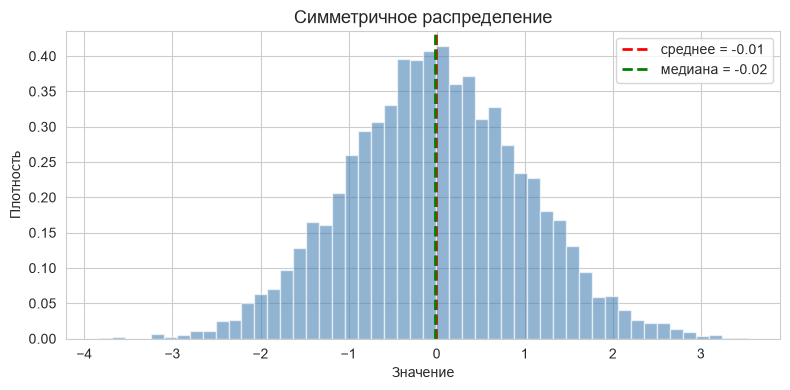

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_sym, bins=50, density=True, alpha=0.6, color='steelblue')
ax.axvline(np.mean(data_sym), color='red', linestyle='--', linewidth=2, label=f'среднее = {np.mean(data_sym):.2f}')
ax.axvline(np.median(data_sym), color='green', linestyle='--', linewidth=2, label=f'медиана = {np.median(data_sym):.2f}')

ax.set_title('Симметричное распределение', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()

plt.tight_layout()
plt.show()

**Правосторонняя (положительная) асимметрия** - распределение скошено в правую сторону
- длинный правый хвост
- среднее > медианы
- «хвост тянет среднее вправо»

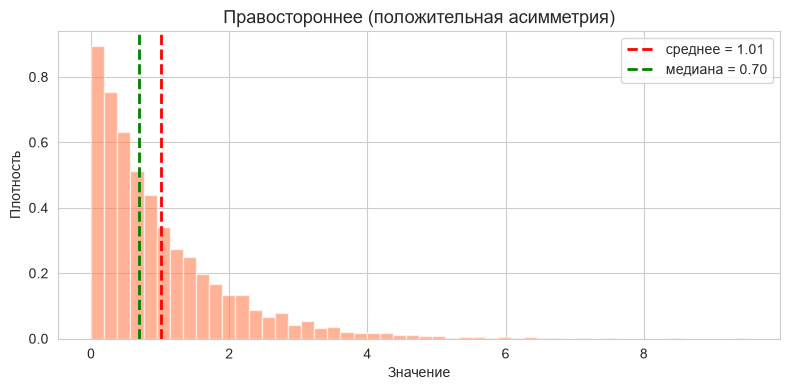

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_right, bins=50, density=True, alpha=0.6, color='coral')
ax.axvline(np.mean(data_right), color='red', linestyle='--', linewidth=2, label=f'среднее = {np.mean(data_right):.2f}')
ax.axvline(np.median(data_right), color='green', linestyle='--', linewidth=2, label=f'медиана = {np.median(data_right):.2f}')

ax.set_title('Правостороннее (положительная асимметрия)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()

plt.tight_layout()
plt.show()

**Левосторонняя (отрицательная) асимметрия** - распределение скошено в левую сторону
- длинный левый хвост
- среднее < медианы
- «хвост тянет среднее влево»

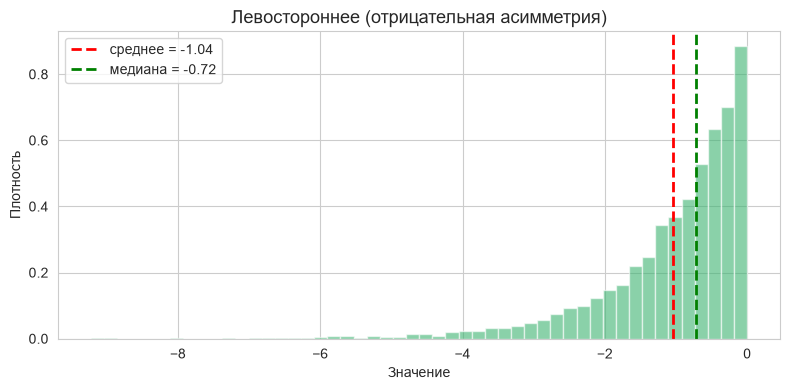

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_left, bins=50, density=True, alpha=0.6, color='mediumseagreen')
ax.axvline(np.mean(data_left), color='red', linestyle='--', linewidth=2, label=f'среднее = {np.mean(data_left):.2f}')
ax.axvline(np.median(data_left), color='green', linestyle='--', linewidth=2, label=f'медиана = {np.median(data_left):.2f}')

ax.set_title('Левостороннее (отрицательная асимметрия)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()

plt.tight_layout()
plt.show()

**Формула (коэффициент асимметрии):**
$$
Skew = \frac{1}{n} \sum (\frac{X_{i} - \bar{x}}{\sigma})^3
$$

- Skew > 0 $\to$ правосторонняя
- Skew < 0 $\to$ левосторонняя
- Skew $\approx$ 0 $\to$ симметричная

### 2. Эксцесс

Эксцесс (kurtosis) - это «острота» пика и «тяжесть» хвостов

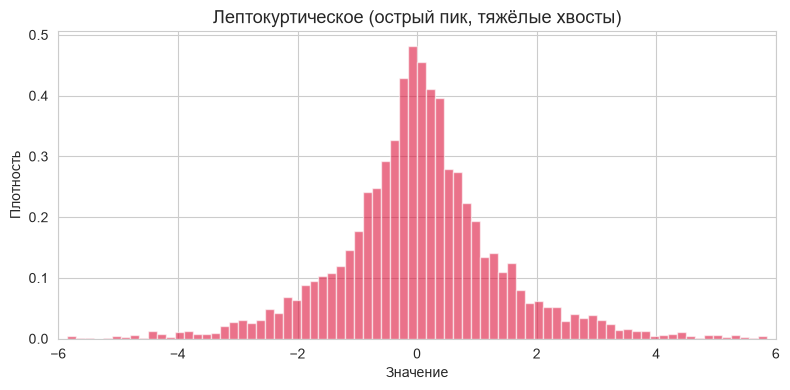

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_lepto, bins=80, density=True, alpha=0.6, color='crimson', range=(-6, 6))

ax.set_title('Лептокуртическое (острый пик, тяжёлые хвосты)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.set_xlim(-6, 6)

plt.tight_layout()
plt.show()

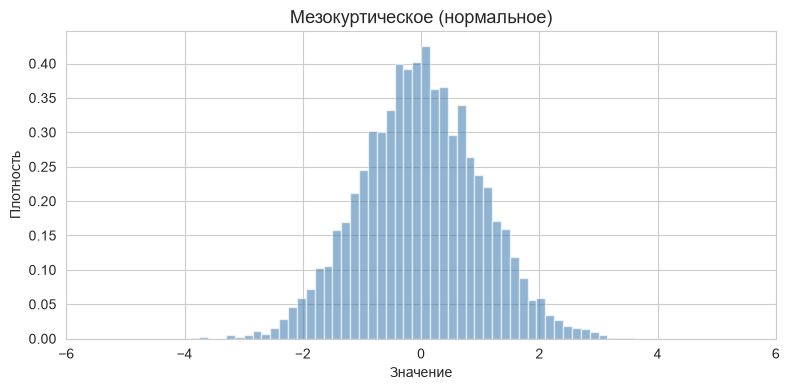

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_sym, bins=80, density=True, alpha=0.6, color='steelblue', range=(-6, 6))

ax.set_title('Мезокуртическое (нормальное)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.set_xlim(-6, 6)

plt.tight_layout()
plt.show()

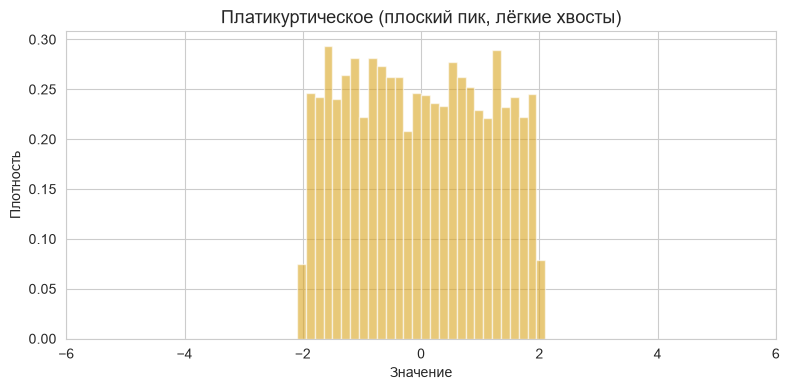

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_platy, bins=80, density=True, alpha=0.6, color='goldenrod', range=(-6, 6))

ax.set_title('Платикуртическое (плоский пик, лёгкие хвосты)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.set_xlim(-6, 6)

plt.tight_layout()
plt.show()

Формула:
$$
Kurt = \frac{1}{n} \sum (\frac{X_{i} - \bar{x}}{\sigma})^4 - 3
$$

- Kurt > 0 $\to$ лептокуртическое (острый пик)
- Kurt = 0 $\to$ мезокуртическое (нормальное)
- Kurt < 0 $\to$ платикуртическое (плоский пик)

### 3. Модальность

**Модальность** - это сколько «горбов» (пиков) у распределения

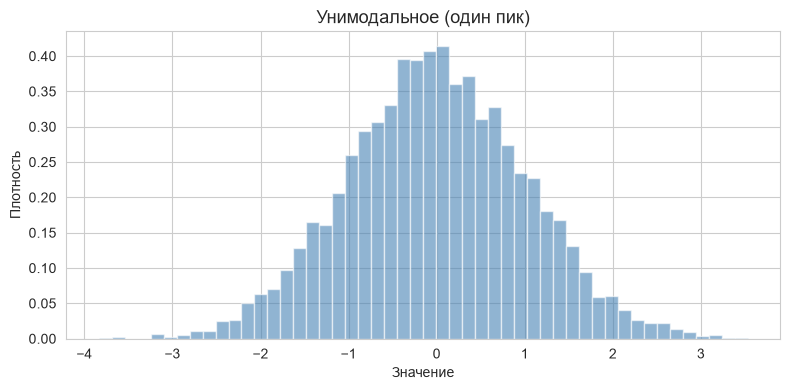

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_sym, bins=50, density=True, alpha=0.6, color='steelblue')

ax.set_title('Унимодальное (один пик)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

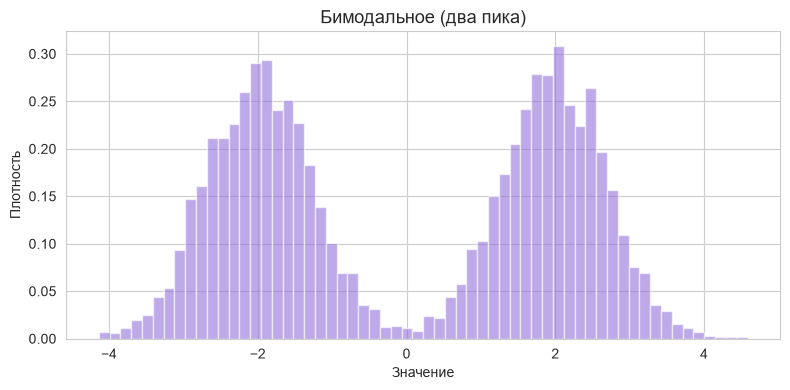

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_bi, bins=60, density=True, alpha=0.6, color='mediumpurple')

ax.set_title('Бимодальное (два пика)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

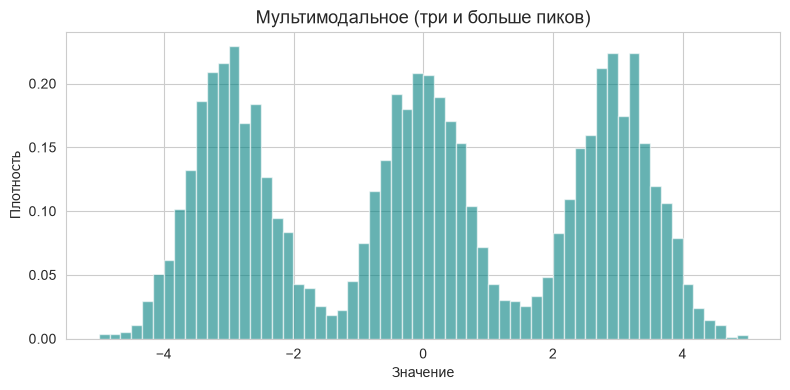

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_multi, bins=60, density=True, alpha=0.6, color='teal')

ax.set_title('Мультимодальное (три и больше пиков)', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

*Бимодальность — сигнал, что данные стоит разделить на группы*

### 4. Визуализация

При помощью чего можно наглядно всё что сказанно выше увидеть:

**Гистограмма** - столбики, показывающие частоты значений

**Ядерная оценка плотности (KDE)** - сглаженная версия гистограммы (рисунок ниже)

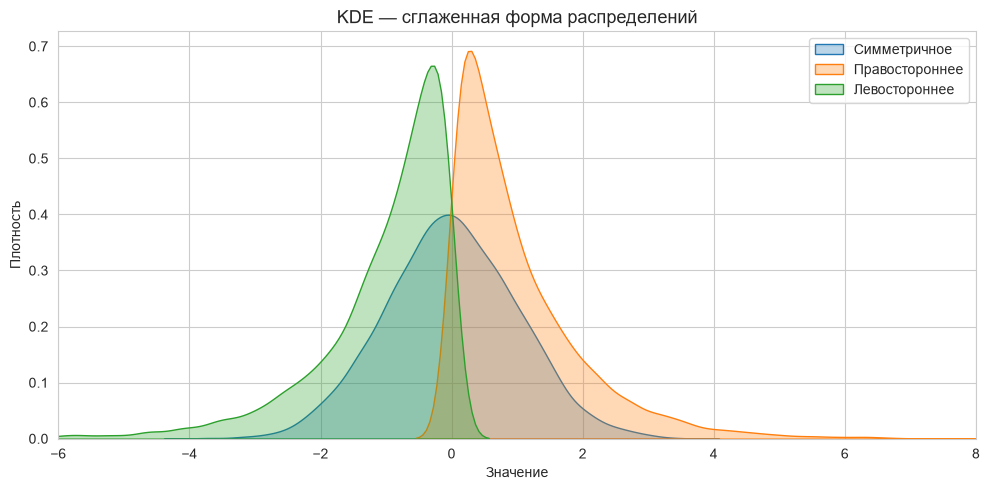

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(data_sym, label='Симметричное', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(data_right, label='Правостороннее', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(data_left, label='Левостороннее', fill=True, alpha=0.3, ax=ax)

ax.set_title('KDE — сглаженная форма распределений', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.set_xlim(-6, 8)
ax.legend()

plt.tight_layout()
plt.show()

**QQ-plot** - сравнивает форму данных с теоретическим распределением (обычно нормальным)
- если точки на прямой → форма совпадает
- если отклоняются → есть асимметрия или тяжёлые хвосты

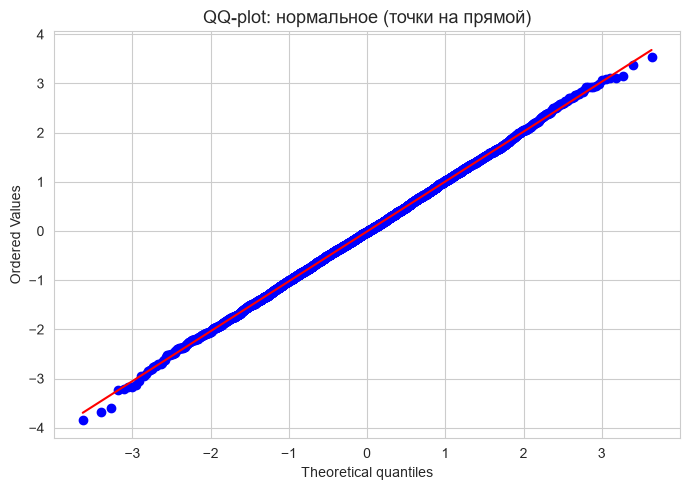

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

stats.probplot(data_sym, dist="norm", plot=ax)

ax.set_title('QQ-plot: нормальное (точки на прямой)', fontsize=13)

plt.tight_layout()
plt.show()

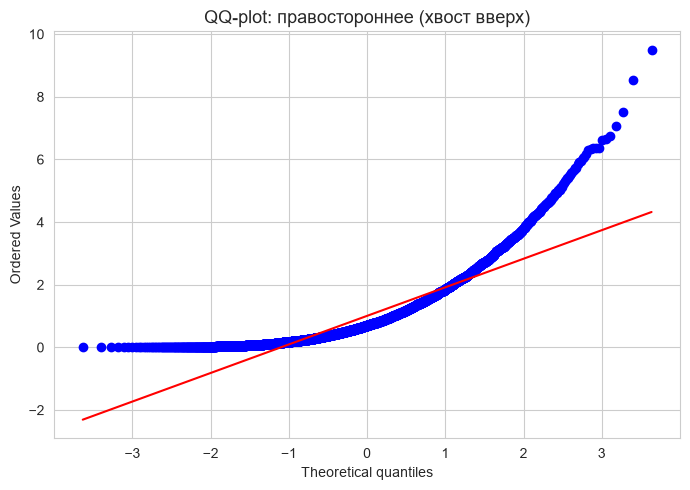

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

stats.probplot(data_right, dist="norm", plot=ax)

ax.set_title('QQ-plot: правостороннее (хвост вверх)', fontsize=13)

plt.tight_layout()
plt.show()

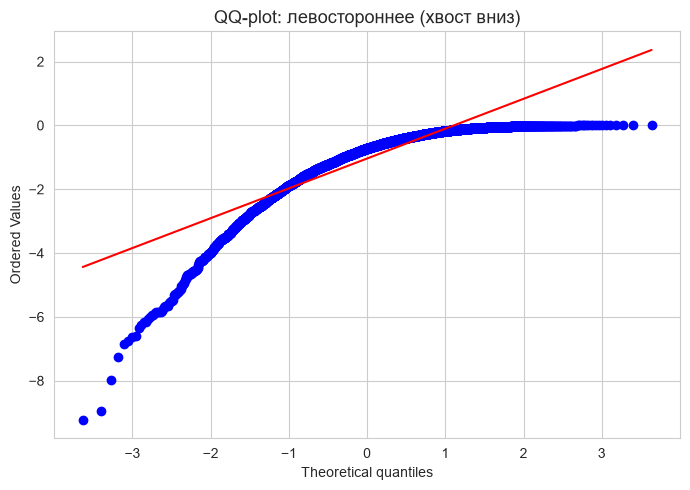

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

stats.probplot(data_left, dist="norm", plot=ax)

ax.set_title('QQ-plot: левостороннее (хвост вниз)', fontsize=13)

plt.tight_layout()
plt.show()

**Box plot** - показывает асимметрию косвенно
- медиана в центре ящика → симметрично
- медиана смещена → асимметрия

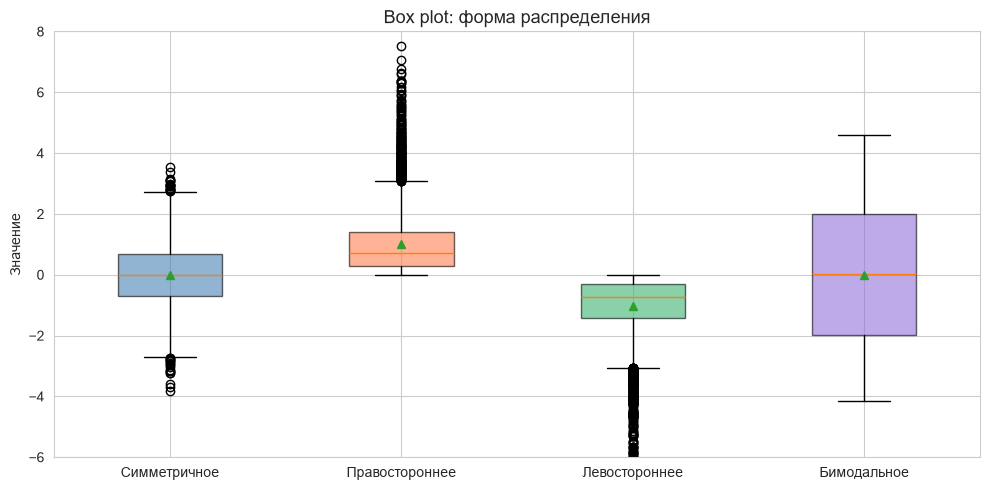

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

data_for_box = [data_sym, data_right, data_left, data_bi]
labels = ['Симметричное', 'Правостороннее', 'Левостороннее', 'Бимодальное']

bp = ax.boxplot(data_for_box, tick_labels=labels, patch_artist=True, showmeans=True)
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('Box plot: форма распределения', fontsize=13)
ax.set_ylabel('Значение')
ax.set_ylim(-6, 8)

plt.tight_layout()
plt.show()

## Визуализация данных

Числа (среднее, медиана, дисперсия) описывают данные абстрактно. Но часто одного взгляда на график достаточно, чтобы понять то, что не видно в цифрах

Основные инструменты:
- Гистограмма — распределение одной величины
- Box plot — сравнение групп и выбросы
- Scatter plot — связь двух величин
- Линейный график — тренд во времени
- Столбчатая — категории
- Heatmap — корреляции
- Pair plot — обзор всего

**Гистограмма** - как часто встречаются значения. Используется для одной числовой величины

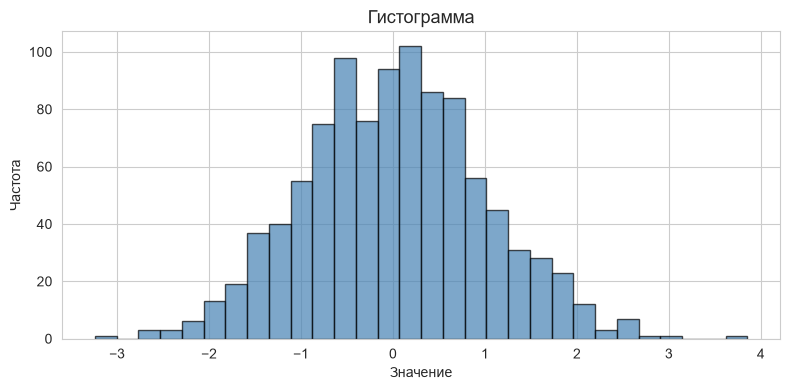

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(data_normal, bins=30, color='steelblue', alpha=0.7, edgecolor='black')

ax.set_title('Гистограмма', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

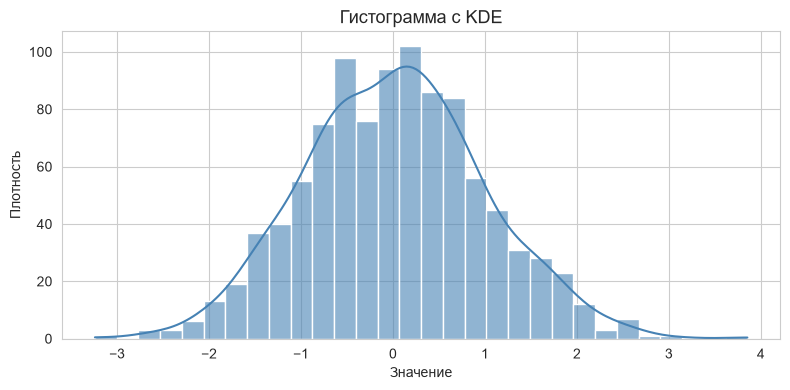

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(data_normal, bins=30, kde=True, color='steelblue', alpha=0.6, ax=ax)

ax.set_title('Гистограмма с KDE', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

**Box plot (ящик с усами)** - для сравнения нескольких групп, для быстрой оценки распределения и для поиска выбросов

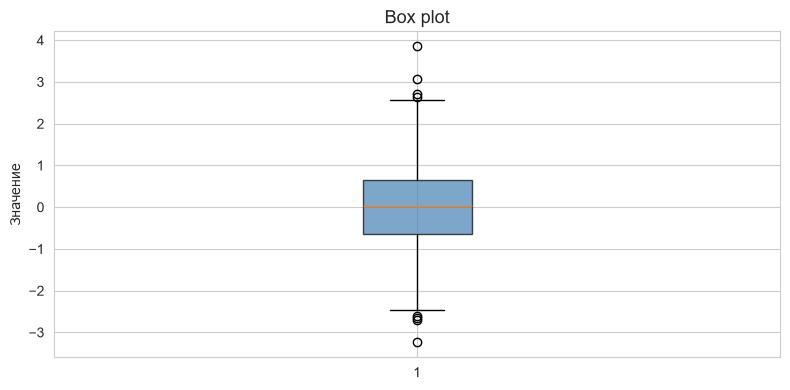

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.boxplot(data_normal, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.7))

ax.set_title('Box plot', fontsize=13)
ax.set_ylabel('Значение')

plt.tight_layout()
plt.show()

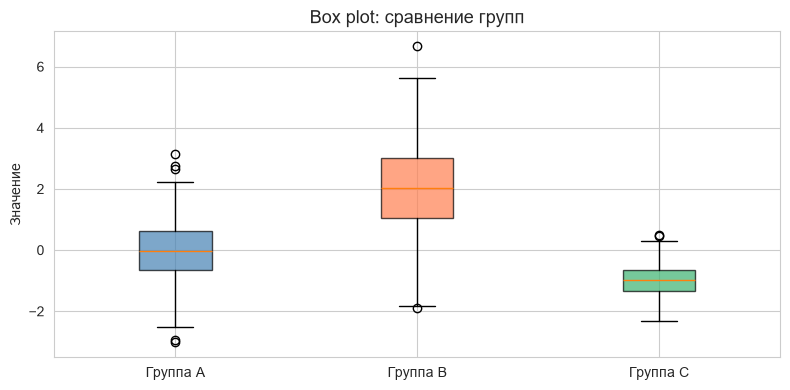

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot([group_a, group_b, group_c],
                tick_labels=['Группа A', 'Группа B', 'Группа C'],
                patch_artist=True)

colors = ['steelblue', 'coral', 'mediumseagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Box plot: сравнение групп', fontsize=13)
ax.set_ylabel('Значение')

plt.tight_layout()
plt.show()

**Violin plot (скрипка)** - комбинация box plot и плотности. Когда box plot недостаточно — нужно увидеть форму

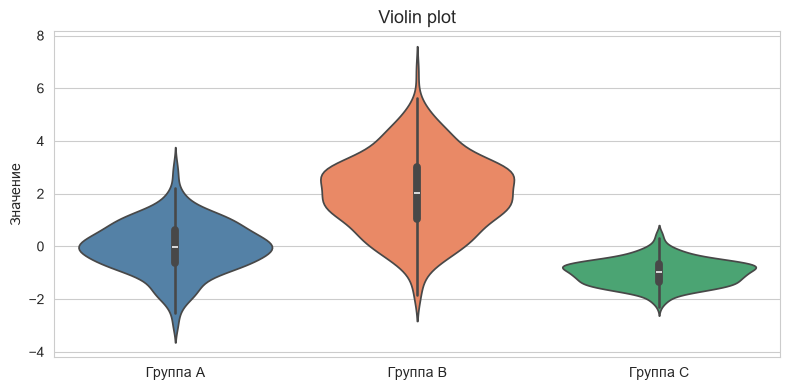

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))

data_for_violin = pd.DataFrame({
    'Группа A': group_a,
    'Группа B': group_b,
    'Группа C': group_c
})

sns.violinplot(data=data_for_violin, palette=['steelblue', 'coral', 'mediumseagreen'], ax=ax)

ax.set_title('Violin plot', fontsize=13)
ax.set_ylabel('Значение')

plt.tight_layout()
plt.show()

**Диаграмма рассеяния (scatter plot)** - связь двух величин

Есть 5 типичных сценария:
- Точки образуют облако, значит ничего необычного
- Точки кучкуются в прямую или кривую линию, значит есть линейная/нелинейная связь
- Точки образуют два и более облака, это сигнал, что в данных несколько групп
- Несколько точек далеко от основного облака, очевидные выбросы
- **Гетероскедастичность** - разброс точек меняется вдоль оси. Например, слева точки кучно, справа разбросаны. Связь есть, но нестабильная

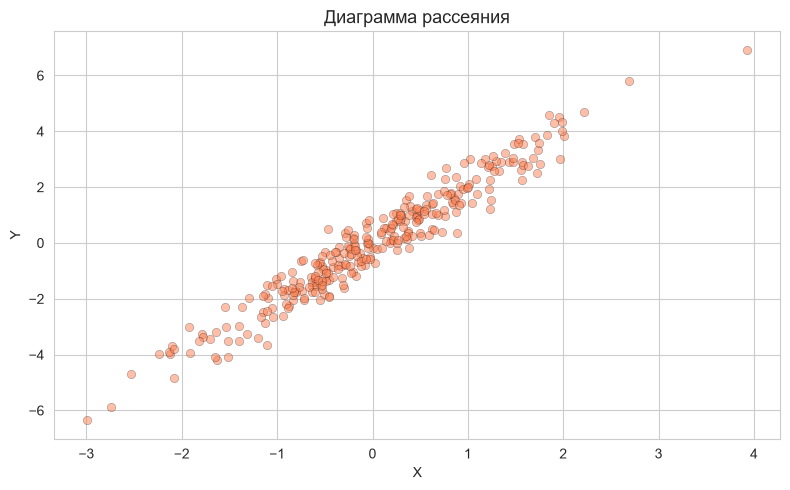

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(x_scatter, y_scatter, alpha=0.5, color='coral', edgecolor='black', linewidth=0.3)

ax.set_title('Диаграмма рассеяния', fontsize=13)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

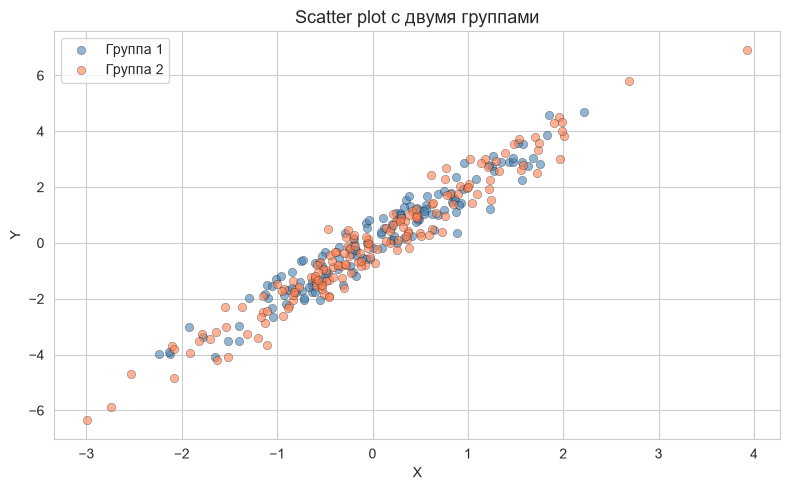

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

mask = np.random.choice([True, False], 300)
ax.scatter(x_scatter[mask], y_scatter[mask], alpha=0.6,
           color='steelblue', label='Группа 1', edgecolor='black', linewidth=0.3)
ax.scatter(x_scatter[~mask], y_scatter[~mask], alpha=0.6,
           color='coral', label='Группа 2', edgecolor='black', linewidth=0.3)

ax.set_title('Scatter plot с двумя группами', fontsize=13)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

plt.tight_layout()
plt.show()

**Линейный график** - изменение величины во времени (или по порядку). Чаще используется когда есть временной промежуток

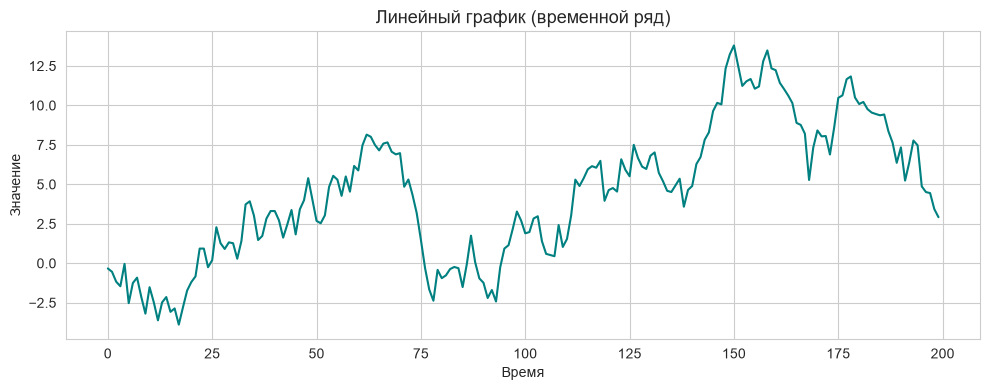

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(time_series, color='teal', linewidth=1.5)

ax.set_title('Линейный график (временной ряд)', fontsize=13)
ax.set_xlabel('Время')
ax.set_ylabel('Значение')

plt.tight_layout()
plt.show()

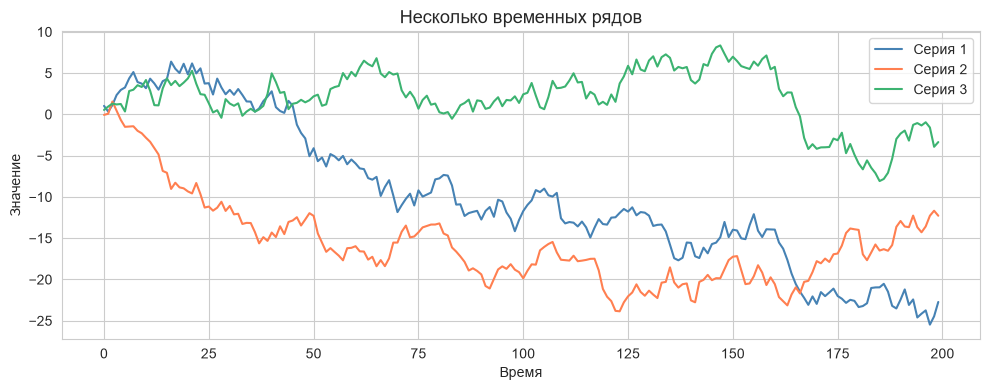

In [44]:
fig, ax = plt.subplots(figsize=(10, 4))

series_1 = np.cumsum(np.random.normal(0, 1, 200))
series_2 = np.cumsum(np.random.normal(0, 1, 200))
series_3 = np.cumsum(np.random.normal(0, 1, 200))

ax.plot(series_1, color='steelblue', label='Серия 1', linewidth=1.5)
ax.plot(series_2, color='coral', label='Серия 2', linewidth=1.5)
ax.plot(series_3, color='mediumseagreen', label='Серия 3', linewidth=1.5)

ax.set_title('Несколько временных рядов', fontsize=13)
ax.set_xlabel('Время')
ax.set_ylabel('Значение')
ax.legend()

plt.tight_layout()
plt.show()

**Столбчатая диаграмма** - сравнение категорий. Для категориальных данных (какая категория чаще, соотношение между категориями)

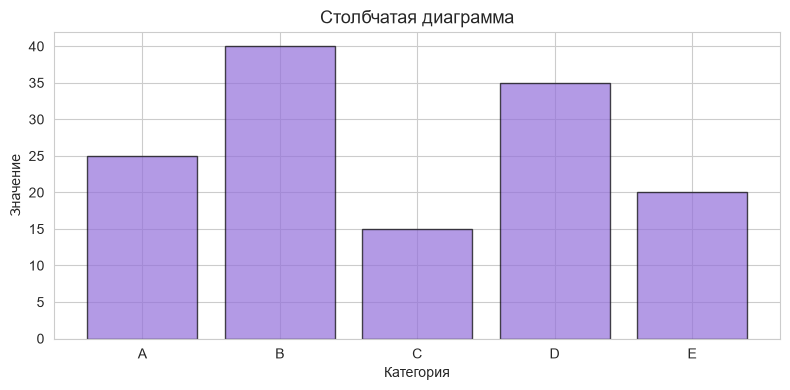

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(categories, cat_values, color='mediumpurple', alpha=0.7, edgecolor='black')

ax.set_title('Столбчатая диаграмма', fontsize=13)
ax.set_xlabel('Категория')
ax.set_ylabel('Значение')

plt.tight_layout()
plt.show()

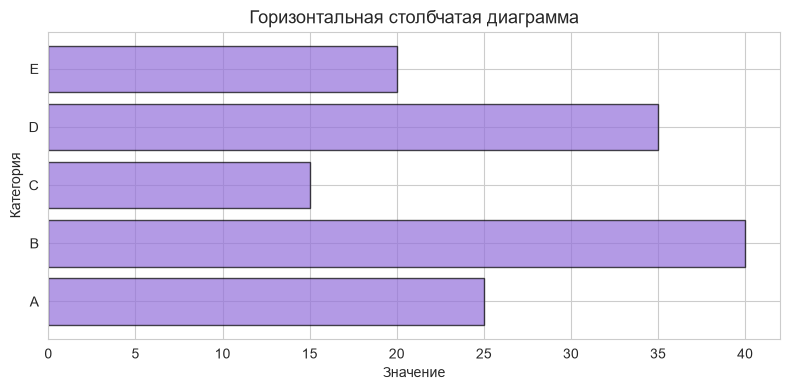

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(categories, cat_values, color='mediumpurple', alpha=0.7, edgecolor='black')

ax.set_title('Горизонтальная столбчатая диаграмма', fontsize=13)
ax.set_xlabel('Значение')
ax.set_ylabel('Категория')

plt.tight_layout()
plt.show()

**Круговая диаграмма** - доли целого. Когда важно соотношение частей (не более 5–7 категорий)

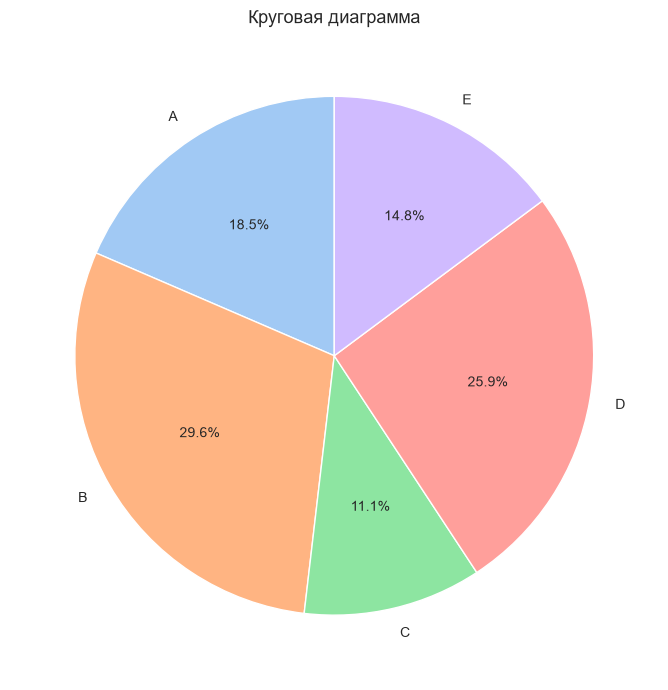

In [47]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(cat_values, labels=categories, autopct='%1.1f%%',
       colors=sns.color_palette('pastel'), startangle=90)

ax.set_title('Круговая диаграмма', fontsize=13)

plt.tight_layout()
plt.show()

**Тепловая карта (heatmap)** - матрица чисел в виде цветов (Чаще всего: матрица корреляций между признаками). Логично для корреляций использовать

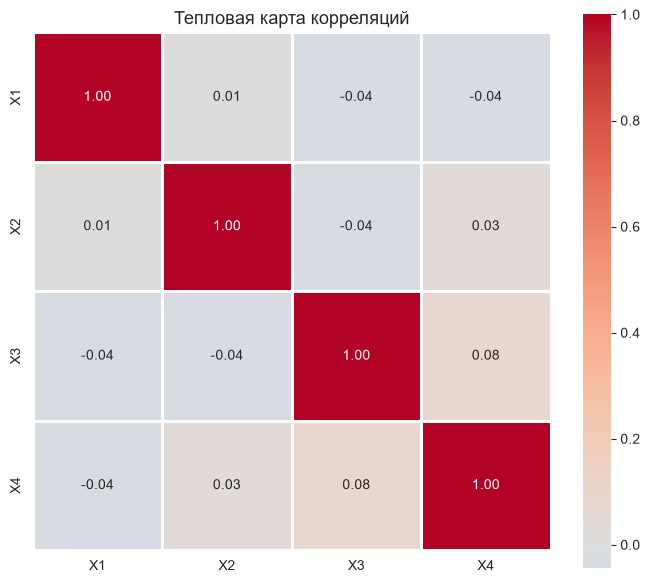

In [48]:
fig, ax = plt.subplots(figsize=(7, 6))

corr = df_multi.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax, fmt='.2f')

ax.set_title('Тепловая карта корреляций', fontsize=13)

plt.tight_layout()
plt.show()

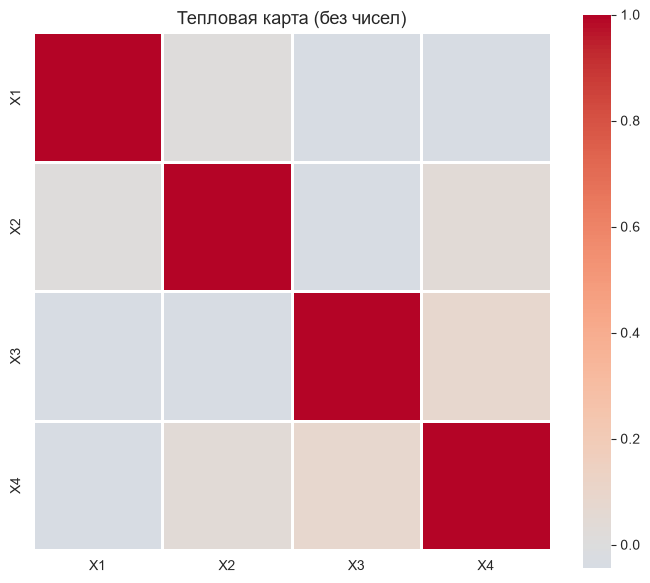

In [49]:
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=1, ax=ax)

ax.set_title('Тепловая карта (без чисел)', fontsize=13)

plt.tight_layout()
plt.show()

**Парные графики (pair plot)** - все пары признаков сразу. Для быстрого обзора многомерных данных

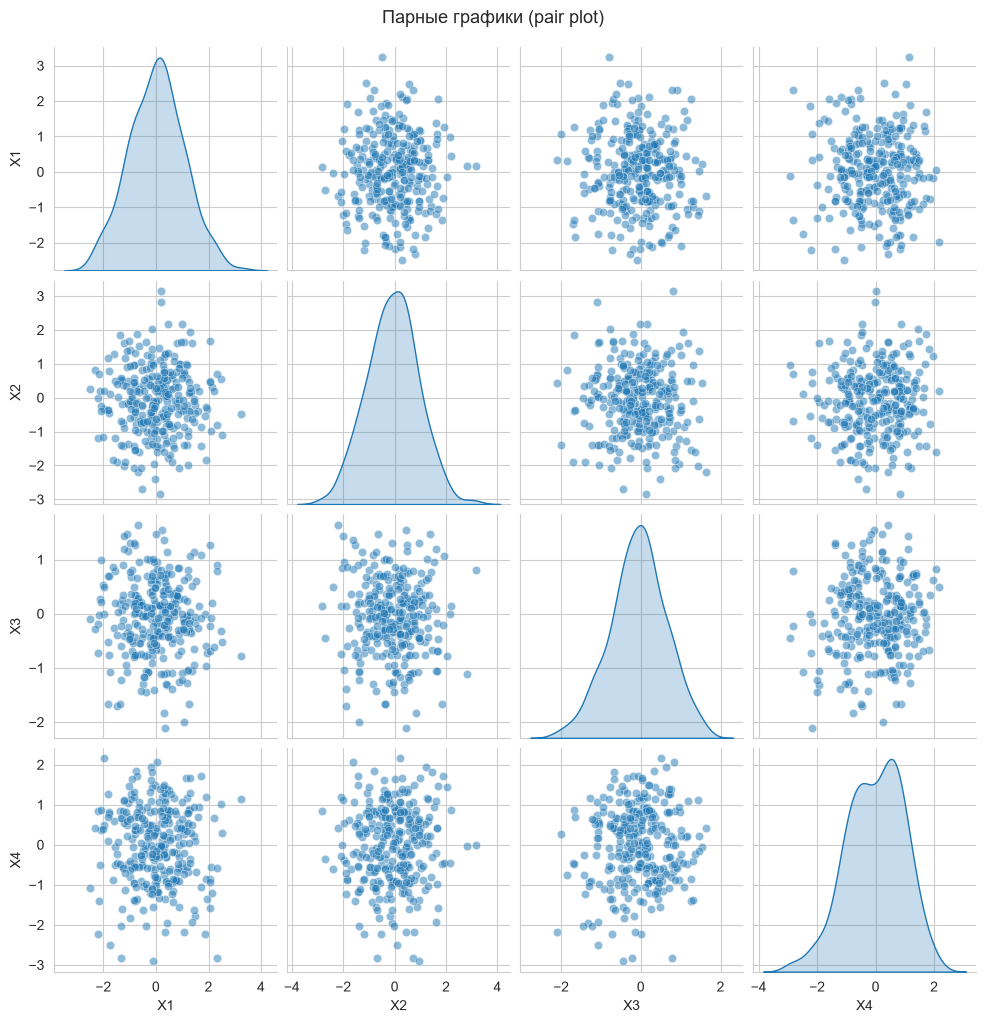

In [50]:
sns.pairplot(df_multi, diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Парные графики (pair plot)', y=1.02, fontsize=13)

plt.show()

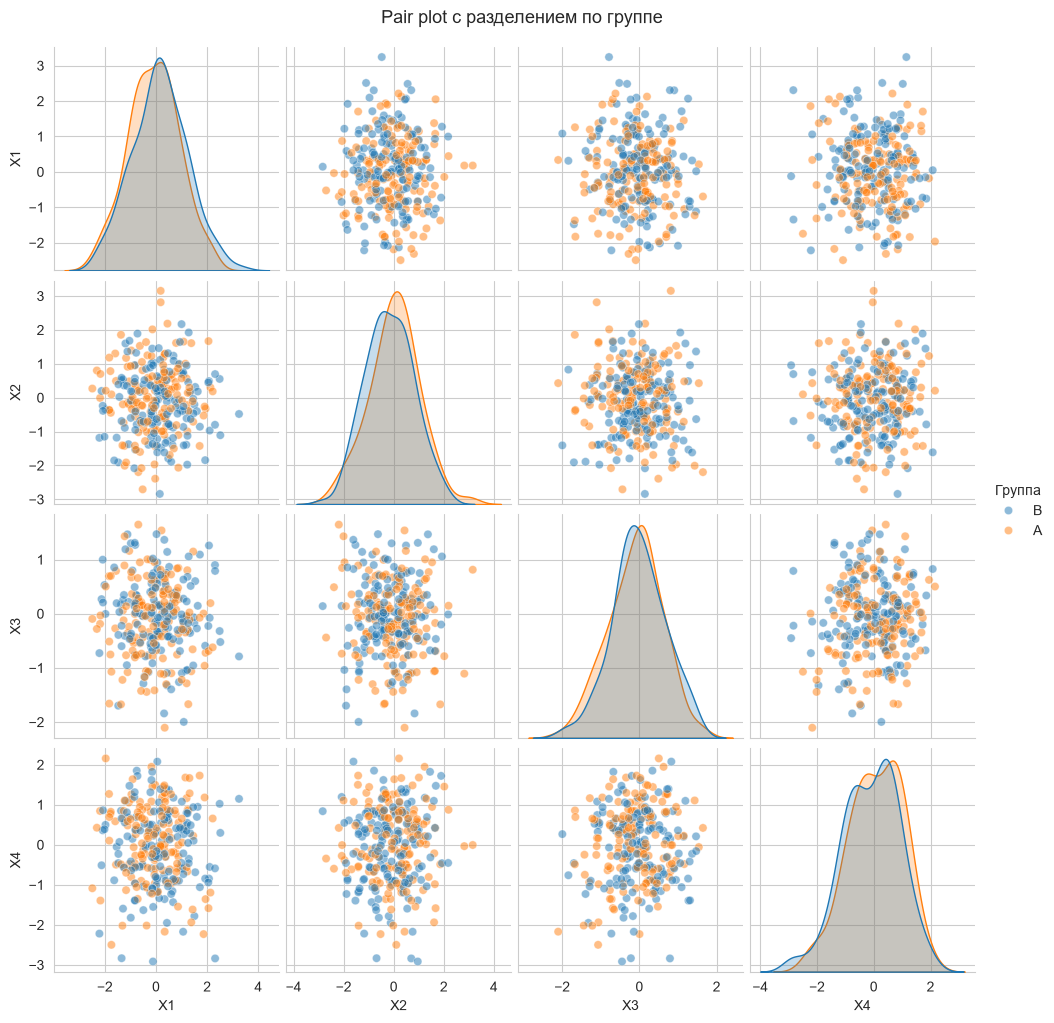

In [51]:
df_with_group = df_multi.copy()
df_with_group['Группа'] = np.random.choice(['A', 'B'], 300)

sns.pairplot(df_with_group, hue='Группа', diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pair plot с разделением по группе', y=1.02, fontsize=13)

plt.show()

C:\Users\wound\AppData\Local\Temp\ipykernel_8484\3954062250.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(data_normal, vert=False, patch_artist=True,


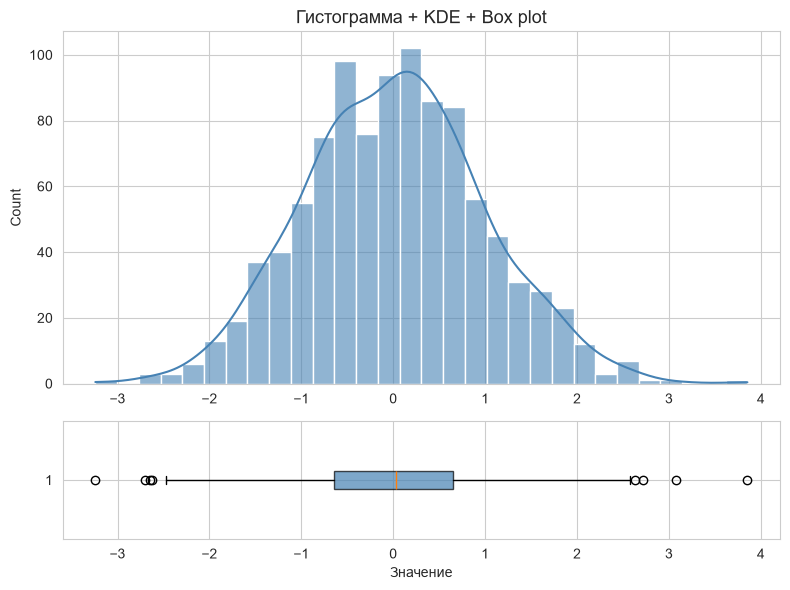

In [52]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6),
                          gridspec_kw={'height_ratios': [3, 1]})

# Гистограмма + KDE
sns.histplot(data_normal, bins=30, kde=True, color='steelblue',
             alpha=0.6, ax=axes[0])
axes[0].set_title('Гистограмма + KDE + Box plot', fontsize=13)
axes[0].set_xlabel('')

# Box plot
axes[1].boxplot(data_normal, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_xlabel('Значение')

plt.tight_layout()
plt.show()

## Связь между переменными

*ВАЖНО! Тут $x$ и $y$ должны быть связанны между собой. Например, как признаки одного объекта. Именно поэтому не возникнет конфликта между $n$* 

### 1. Ковариация

**Ковариация** - мера того, насколько согласованно две переменные отклоняются от своих средних
$$
Cov(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_{i} - \bar{x}) (y_{i} - \bar{y})
$$
- $Cov > 0$ - когда X растёт, Y тоже растёт
- $Cov < 0$ - когда X растёт, Y падает
- $Cov \approx 0$ - линейной связи нет

### 2. Корреляция Пирсона

**Корреляция Пирсона** - нормированная ковариация. Безразмерная. Всегда от -1 до 1. Не видит нелинейные связи
$$
r = \frac{Cov(X,Y)}{\sigma_{X} * \sigma_{Y}}
$$

- r = 1 $\to$ идеальная положительная линейная связь
- 0 < r < 1 $\to$ положительная линейная связь
- r = 0 $\to$ линейной связи нет
- -1 < r < 0 $\to$ отрицательная линейная связь
- r = -1 $\to$ идеальная отрицательная линейная связь

### 3. Корреляция Спирмена

**Корреляция Спирмена** - это корреляция рангов, а не самих значений. Она показывает, насколько согласованно упорядочены две переменные
$$
p = 1 - \frac{6 \sum d_{i}^{2}}{n(n^2 - 1)}
$$
Где $d_{i}$ - разность рангов

Про ранги:
1. Сортируем столбец и к каждому значению записываем его позицию
2. Возвращаемся к изначальному виду, но с учётом привязанных к значениям позиций
3. Тоже самое для второго столбца и для каждой строки просто вычитаем не значения, а позиции между двумя столбцами. Это и будет $d$

Подходит для:
- когда связь монотонная, но не линейная
- когда есть выбросы (Спирмен устойчивее)
- для порядковых данных

*Различие: Пирсон чувствителен к форме (линейная или нет). Спирмен — только к порядку*

### 4. Квартет Анскомба (иллюстрация)

Тут мысль простая. Брали совершенно разные данные, которые дали одинаковые числовые величины (среднее, дисперсию, корреляцию, уравнение регрессии), но на графиках они все отличались. Вывод: важно **ВСЕГДА** проверять визуализацию, а не только числа!

### 5. Корреляция ≠ причинность

Главное правило: если $X$ и $Y$ коррелируют, это не значит, что $X$ вызывает $Y$

Примеры:
- Продажи мороженого и утопления коррелируют. Причина не в мороженом, а в лете
- Количество церквей и преступлений коррелируют. Причина не в церквях, а в размере города
- Рост и математические способности у детей коррелируют. Причина не в росте, а в возрасте

Возможные объяснения корреляции:
- X вызывает Y
- Y вызывает X
- Третья переменная Z влияет на оба
- Случайность